In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
from scripts.common import add_galactic, mollweide_scatter

ztf_styles = {
    'z_snid':      {'color': '#1f77b4', 'marker': 'o'},
    'z_gal':       {'color': '#ff7f0e', 'marker': 's'},
    'z_SEDm':      {'color': '#2ca02c', 'marker': '^'},
    'z_nonSEDm':   {'color': '#d62728', 'marker': 'D'},
    'z_override':  {'color': '#9467bd', 'marker': 'v'},
    'z_unknown':   {'color': '#8c564b', 'marker': 'p'},
}

In [45]:
try:
    import ztfcosmo
    data_ztfcosmo = ztfcosmo.get_data()
    print(f"ztfcosmo data: {len(data_ztfcosmo)} SNe, {len(data_ztfcosmo.columns)} columns")
    
    sn_data_z = data_ztfcosmo[data_ztfcosmo['source'] == 'z_snid']
    print(f"z_snid subset: {len(sn_data_z)} SNe")
    print(f"ztfcosmo columns: {list(data_ztfcosmo.columns)}")
except ImportError:
    print("ztfcosmo not installed — skipping this section")

ztfcosmo data: 3628 SNe, 40 columns
z_snid subset: 1081 SNe
ztfcosmo columns: ['redshift', 'redshift_err', 'source', 't0', 'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0', 'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv', 'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type', 'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted', 'ra_host', 'dec_host', 'globalmass', 'globalmass_err', 'globalrestframe_gz', 'globalrestframe_gz_err', 'd_dlr', 'localmass', 'localmass_err', 'localrestframe_gz', 'localrestframe_gz_err']


In [46]:
sn_csv = Path('../data/ztf/ztfsniadr2_lite/tables/snia_data.csv')
host_csv = Path('../data/ztf/ztfsniadr2_lite/tables/globalhost_data.csv')

df = pd.read_csv(sn_csv, comment='#')
print(f"SN lightcurve data: {len(df)} rows, {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

SN lightcurve data: 3628 rows, 31 columns
Columns: ['Unnamed: 0', 'ztfname', 'redshift', 'redshift_err', 'source', 't0', 'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0', 'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv', 'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type', 'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted']


In [47]:
print("\nSurvey (source) distribution:")
print(df["source"].value_counts().to_string())
print(f"\nSN type distribution:")
print(df["sn_type"].value_counts().to_string())


Survey (source) distribution:
source
z_gal         2203
z_snid        1081
z_nonSEDm      199
z_SEDm         121
z_override      12
z_unknown       12

SN type distribution:
sn_type
snia-cosmo    2800
snia           666
snia-pec       162


In [48]:
hosts = pd.read_csv(host_csv, comment='#')
print(f"Host data: {len(hosts)} rows")
print(f"Host columns: {list(hosts.columns)}")

df = df.merge(hosts[['ztfname', 'mass']], on='ztfname', how='left')
has_mass = df['mass'].notna().sum()
print(f"After merge: {len(df)} rows, {has_mass} with host masses")

Host data: 3628 rows
Host columns: ['ztfname', 'ra_host', 'dec_host', 'mass', 'mass_err', 'restframe_gz', 'restframe_gz_err', 'd_dlr']
After merge: 3628 rows, 3534 with host masses


In [49]:
df['l'], df['b'] = add_galactic(df['ra'].values, df['dec'].values)
print(f"Galactic coords added. Sample:\n{df[['ztfname', 'ra', 'dec', 'l', 'b']].head()}")

Galactic coords added. Sample:
        ztfname          ra        dec           l          b
0  ZTF17aadlxmv  127.448018  33.906536  188.742628  34.174488
1  ZTF18aaadqua   26.798708  18.798611  140.838881 -42.126173
2  ZTF18aaanzph  157.743465  23.788356  211.007722  58.219943
3  ZTF18aaapivw  102.563278  27.140073  188.296727  11.765736
4  ZTF18aaaqexr  175.776516  15.567129  245.540551  70.370729


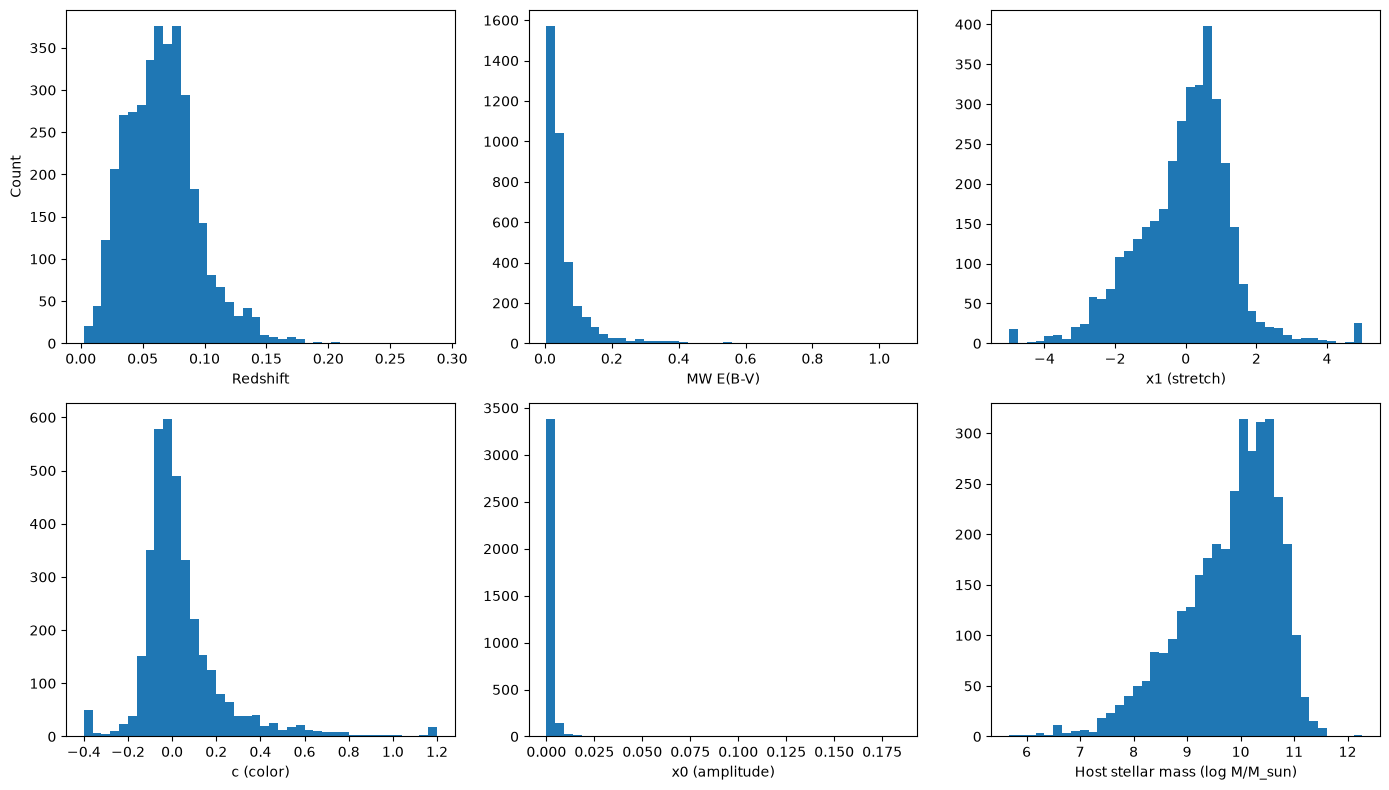

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(df['redshift'], bins=40)
axes[0, 0].set_xlabel("Redshift")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df['mwebv'], bins=40)
axes[0, 1].set_xlabel("MW E(B-V)")

axes[0, 2].hist(df['x1'], bins=40)
axes[0, 2].set_xlabel("x1 (stretch)")

axes[1, 0].hist(df['c'], bins=40)
axes[1, 0].set_xlabel("c (color)")

axes[1, 1].hist(df['x0'], bins=40)
axes[1, 1].set_xlabel("x0 (amplitude)")

mass = df['mass'].dropna()
axes[1, 2].hist(mass, bins=40)
axes[1, 2].set_xlabel("Host stellar mass (log M/M_sun)")

plt.tight_layout()
plt.show()

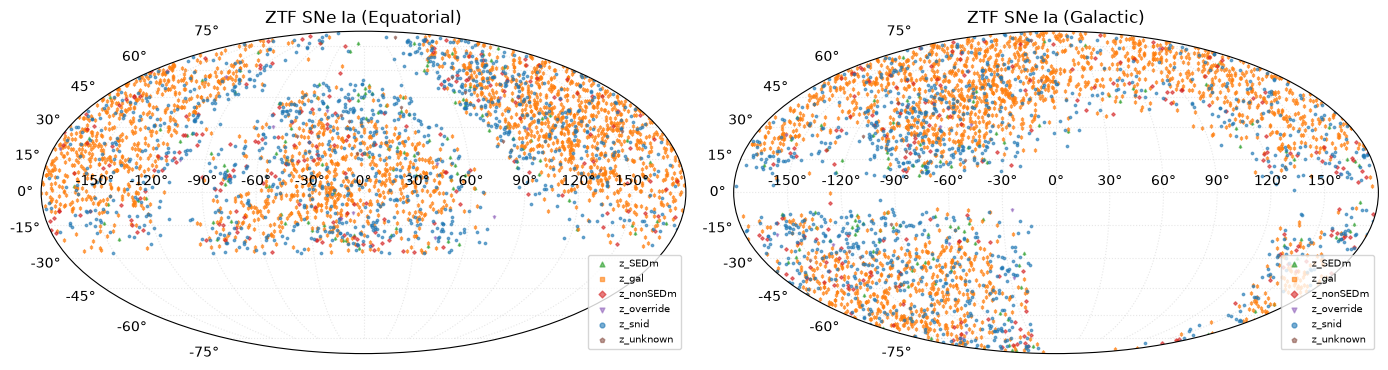

In [51]:
df['group'] = df['source'].fillna('z_unknown')

fig = plt.figure(figsize=(14, 6))
ax0 = plt.subplot(1, 2, 1, projection='mollweide')
mollweide_scatter(ax0, df['ra'], df['dec'], df['group'], ztf_styles,
                  'ZTF SNe Ia (Equatorial)')

ax1 = plt.subplot(1, 2, 2, projection='mollweide')
mollweide_scatter(ax1, df['l'], df['b'], df['group'], ztf_styles,
                  'ZTF SNe Ia (Galactic)')
plt.tight_layout()
plt.show()

In [52]:
print("=== Summary Statistics ===")
print(f"Total SNe: {len(df)}")
print(f"Redshift range: {df["redshift"].min():.4f} - {df["redshift"].max():.4f}")
print(f"Source types: {df["source"].nunique()}")
print(f"SN types: {df["sn_type"].unique()}")
print(f"SNe with host mass: {df["mass"].notna().sum()} / {len(df)}")

=== Summary Statistics ===
Total SNe: 3628
Redshift range: 0.0025 - 0.2878
Source types: 6
SN types: <StringArray>
['snia-cosmo', 'snia-pec', 'snia']
Length: 3, dtype: str
SNe with host mass: 3534 / 3628
